# Vision Transformers (ViT)

**Domain:** `deep-learning`
**Level:** Intermediate
**Prerequisites:** basic Python and numpy; basic neural network familiarity
(see `perceptron-and-backpropagation`); helpful but not required — a skim of
`nlp/transformer-self-attention`, since this tutorial reuses (but does not
re-derive) its self-attention math

## Intro: teaching a sentence-reader to look at pictures

A Transformer for text reads a sentence as a **sequence of words**: split the
sentence into tokens, turn each token into a vector, and let self-attention
figure out how the tokens relate to each other. That machinery — covered in
depth in this repo's `nlp/transformer-self-attention` tutorial — has no
special knowledge of *language*. It just operates on a sequence of vectors.

A **Vision Transformer (ViT)** asks a simple question: what if an image
*is* a sequence too? Instead of chopping a sentence into words, chop a
photograph into a grid of small square **patches** — think of it as cutting
a photo into puzzle pieces and handing them, in reading order, to a reader
who only knows how to read sentences. Each puzzle piece becomes one "visual
word" in the sequence, and the exact same self-attention machinery that
relates words to each other now relates image patches to each other.

That's the entire idea. The rest of this tutorial is about making it precise
and building one. By the end you will be able to:

- Explain, with a picture, how an image becomes a sequence of "visual word"
  tokens (patch embedding).
- State precisely why ViTs need an explicit `[CLS]` token and positional
  embeddings, and what shape every intermediate tensor has.
- Read a real pretrained ViT's attention weights and see, on a real photo,
  which patches the model actually looks at.
- Build a small Vision Transformer from scratch in PyTorch and train it on
  real image data.
- Reason about when ViTs beat CNNs and when they don't — this is still an
  active, unsettled debate in the field, not a solved question.

In [1]:
import os
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn

torch.manual_seed(0)
rng = np.random.default_rng(0)

DEVICE = "cpu"  # this tutorial is written and tested on a CPU-only machine
print("torch:", torch.__version__)

torch: 2.12.0+cpu


## The idea, intuitively

### Slicing a photo into "visual words"

Before any equations, let's just *look* at what "image as a sequence of
patches" means. We'll download one real photo, cut it into a grid of square
patches with plain numpy slicing (no deep learning yet), and look at the
grid.

In [2]:
os.makedirs("_vit_images_data", exist_ok=True)

def download_image(url, path):
    if not os.path.exists(path):
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        data = urllib.request.urlopen(req).read()
        with open(path, "wb") as f:
            f.write(data)
    return path

dog_path = download_image(
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "_vit_images_data/dog.jpg",
)
cat_path = download_image(
    "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/500px-Cat03.jpg",
    "_vit_images_data/cat.jpg",
)
print("downloaded:", dog_path, cat_path)

downloaded: _vit_images_data/dog.jpg _vit_images_data/cat.jpg


In [3]:
# Load the image and resize to a square so it divides evenly into patches
img = Image.open(dog_path).convert("RGB").resize((224, 224))
img_arr = np.asarray(img)  # shape (H, W, C) = (224, 224, 3), uint8

P = 32  # patch side length in pixels
H, W, C = img_arr.shape
n_rows, n_cols = H // P, W // P  # 7 x 7 grid of patches

# The whole "image -> sequence of patches" idea in four lines of numpy:
# split H into (n_rows, P) and W into (n_cols, P), then move the patch-grid
# axes to the front so patches[i, j] is one P x P x C patch.
patches = img_arr.reshape(n_rows, P, n_cols, P, C)
patches = patches.transpose(0, 2, 1, 3, 4)  # (n_rows, n_cols, P, P, C)
print("image shape:", img_arr.shape)
print("patch grid shape:", patches.shape, f"-> {n_rows * n_cols} patches of {P}x{P}x{C}")

image shape:

 (224, 224, 3)
patch grid shape: (7, 7, 32, 32, 3) -> 49 patches of 32x32x3


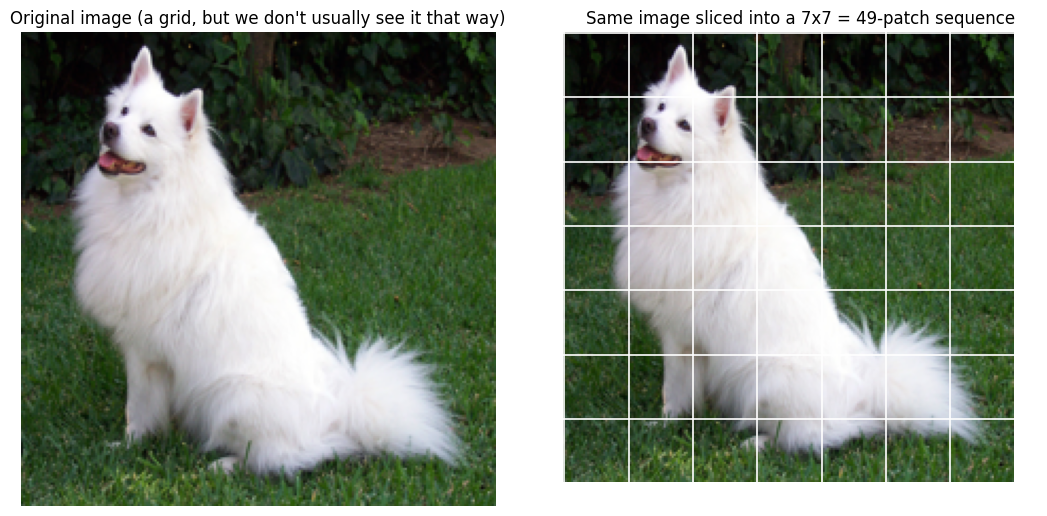

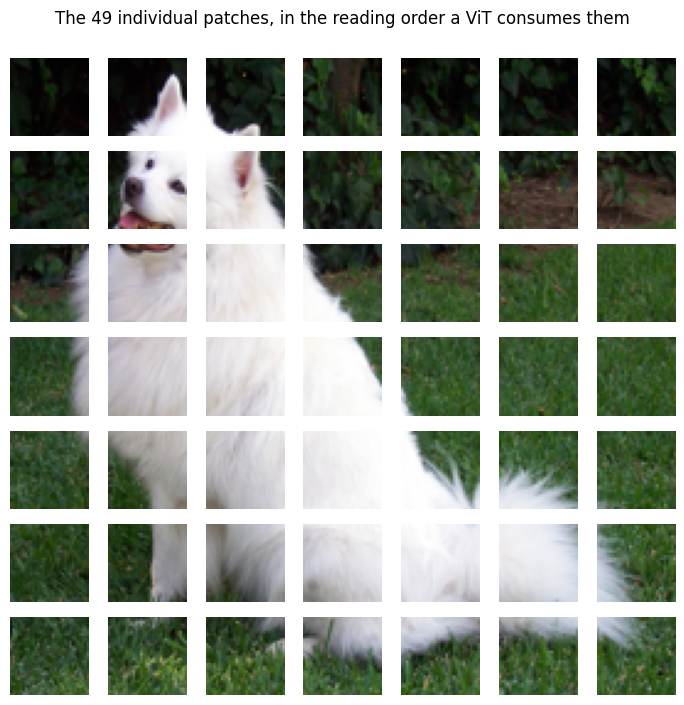

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
axes[0].imshow(img_arr)
axes[0].set_title("Original image (a grid, but we don't usually see it that way)")
axes[0].axis("off")

# Re-draw the same image, but now with the patch grid lines drawn on top,
# and each patch given a thin border -- exactly the "puzzle pieces" a ViT sees
axes[1].imshow(img_arr)
for i in range(n_rows + 1):
    axes[1].axhline(i * P, color="white", linewidth=1.2)
for j in range(n_cols + 1):
    axes[1].axvline(j * P, color="white", linewidth=1.2)
axes[1].set_title(f"Same image sliced into a {n_rows}x{n_cols} = {n_rows*n_cols}-patch sequence")
axes[1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 7))
for i in range(n_rows):
    for j in range(n_cols):
        axes[i, j].imshow(patches[i, j])
        axes[i, j].axis("off")
plt.suptitle("The 49 individual patches, in the reading order a ViT consumes them", y=1.0)
plt.tight_layout()
plt.show()

Every one of those 49 small tiles is one token in the sequence a ViT will
process — no different, structurally, from one word in a sentence. **The
entire rest of this tutorial is about how a patch, a small grid of raw
pixels, turns into a vector the same self-attention machinery from the NLP
transformer tutorial can operate on, and how the model puts the sequence
back together into a single prediction.**

Notice we did this with `reshape` and `transpose` — no neural network
involved yet. The neural network's job starts one step later: turning each
raw pixel patch into a learned embedding vector.

## Going deeper: the formal definition

This section follows Dosovitskiy et al. (2020), *"An Image is Worth 16x16
Words: Transformers for Image Recognition at Scale"* — the paper that
introduced ViT. We define patch embedding, the `[CLS]` token, positional
embeddings, and the encoder forward pass precisely. We restate (but do not
re-derive) the self-attention equation itself — the full derivation,
including *why* the $1/\sqrt{d_k}$ scaling term is necessary, lives in
`nlp/transformer-self-attention`.

### Patch embedding

An input image is a tensor $x \in \mathbb{R}^{H \times W \times C}$ (height,
width, channels). Split it into a grid of $N$ non-overlapping square patches
of side length $P$:

$$
N = \frac{HW}{P^2}
$$

That's exactly the $7 \times 7 = 49$ patches from the picture above, with
$H=W=224$, $P=32$: $N = 224 \cdot 224 / 32^2 = 49$.

Each patch is flattened into a single vector of length $P^2 C$ (all its
pixels, across all channels, laid out in one row), giving a sequence of $N$
flattened patch vectors $x_p^i \in \mathbb{R}^{P^2 C}$ for $i = 1, \dots, N$.
A single learned linear projection — the **patch embedding matrix**
$E \in \mathbb{R}^{(P^2 C) \times D}$ — maps every flattened patch into a
shared $D$-dimensional embedding space:

$$
z_0^i = x_p^i E, \qquad z_0^i \in \mathbb{R}^{D}, \quad i = 1, \dots, N
$$

In code, this "flatten each patch then linearly project it" is implemented
efficiently as a single strided convolution with kernel size $P$ and stride
$P$ (a $P \times P$ conv filter that never overlaps itself is mathematically
identical to flatten-then-matmul, just faster) — we use exactly that trick
in the implementation below.

### The `[CLS]` token

Following BERT's convention, ViT prepends one extra **learnable** embedding,
$x_{\text{class}} \in \mathbb{R}^D$, to the front of the patch sequence. This
token is not tied to any patch of the image — its whole job is to be a
"summary slot" that attention can write information into over the course of
the encoder. After the final layer, *only this token's* representation is
read out and fed to the classification head; every other position is
discarded at the end. The sequence length becomes $N + 1$.

### Positional embeddings

Self-attention (see below) is **permutation-invariant**: shuffle the input
tokens and, without extra information, attention produces the same
outputs in the same shuffled order — it has no innate sense that patch 3
is above patch 10, or that two patches are neighbors. Since patch order
*does* carry real spatial information, ViT adds a learnable positional
embedding vector to every token (the original paper also tried fixed
sinusoidal encodings, as used for text, and found learned ones worked
about as well for images):

$$
z_0 = \big[x_{\text{class}};\; x_p^1 E;\; x_p^2 E;\; \dots;\; x_p^N E\big] +
E_{\text{pos}}, \qquad E_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}
$$

$z_0 \in \mathbb{R}^{(N+1) \times D}$ is the actual input to the transformer
encoder: $N+1$ tokens (1 class token + $N$ patches), each a $D$-dimensional
vector that already encodes both *what* the patch looks like and *where* it
sits in the image.

### Self-attention, restated

Each encoder layer's core operation is the same **scaled dot-product
attention** derived in full in `nlp/transformer-self-attention`. Given
query, key, and value matrices $Q, K, V$ (linear projections of the token
embeddings) with key dimension $d_k$:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

**Multi-head** attention runs $h$ independent copies of this in parallel on
different learned projections, concatenates the results, and mixes them
with one more linear layer — again, see the NLP tutorial for the full
derivation of why the $1/\sqrt{d_k}$ term matters and how multiple heads are
combined. Everything ViT adds on top is *what gets fed into* attention
(image patches instead of word tokens) — the attention math itself is
identical.

### The full ViT forward pass

Each of the $L$ transformer encoder blocks applies pre-norm multi-head
self-attention (MSA) and an MLP, each wrapped in a residual connection:

$$
z_\ell' = \text{MSA}\big(\text{LN}(z_{\ell-1})\big) + z_{\ell-1}, \qquad
z_\ell = \text{MLP}\big(\text{LN}(z_\ell')\big) + z_\ell', \qquad \ell = 1,
\dots, L
$$

where $\text{LN}$ is layer normalization and the MLP is two linear layers
with a GELU nonlinearity in between (the transformer's per-token
feed-forward block). After the last layer, only the class token's row is
read out and normalized, then passed through a classification head (a
single linear layer for a small model, an MLP with one hidden layer in the
original ViT paper's pretraining setup):

$$
y = \text{Head}\big(\text{LN}(z_L^0)\big)
$$

where $z_L^0$ denotes row 0 (the class token) of the final layer's output.
Put in one sentence: **patch-embed the image into a sequence, prepend a
class token, add position information, run it through ordinary transformer
encoder blocks, and classify off the class token's final vector** — nothing
about the encoder blocks themselves is vision-specific.

## Visuals: what does the `[CLS]` token actually attend to?

The formal definition says attention lets every token exchange information
with every other token. Does a trained model actually learn to point the
class token's attention at *meaningful* parts of the image, or is it doing
something opaque? Let's check on a real pretrained ViT and a real photo,
rather than take it on faith.

We load `torchvision`'s `vit_b_16` with its official ImageNet-pretrained
weights, run our dog photo through it, and pull out the last encoder
block's attention weights *from the class token to every patch*. Torchvision's
`EncoderBlock.forward` hard-codes `need_weights=False` for speed, so we
capture the tensor that block's `self_attention` module was about to
consume (via a forward hook on the preceding LayerNorm) and re-run just that
one attention module with `need_weights=True` to recover the actual weights
— without altering the model's real forward pass or its prediction.

In [5]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit = vit_b_16(weights=weights)
vit.eval()
preprocess = weights.transforms()
categories = weights.meta["categories"]

print("ViT-B/16 loaded:", sum(p.numel() for p in vit.parameters()) / 1e6, "M parameters")
print("patch size:", vit.patch_size, " hidden dim:", vit.hidden_dim,
      " encoder layers:", len(vit.encoder.layers))

ViT-B/16 loaded: 86.567656 M parameters
patch size: 16  hidden dim: 768  encoder layers: 12


In [6]:
def cls_attention_map(model, pil_image, preprocess):
    """Run the model once, recover the last encoder block's attention from the
    class token to every patch token, and return it as a square grid."""
    batch = preprocess(pil_image).unsqueeze(0)

    captured = {}
    def capture_ln1_output(module, inputs, output):
        captured["x"] = output.detach()

    last_block = model.encoder.layers[-1]
    handle = last_block.ln_1.register_forward_hook(capture_ln1_output)
    with torch.no_grad():
        logits = model(batch)
    handle.remove()

    x = captured["x"]  # (1, N+1, D): input the real forward pass fed to attention
    with torch.no_grad():
        _, attn_weights = last_block.self_attention(
            x, x, x, need_weights=True, average_attn_weights=True
        )  # (1, N+1, N+1), averaged over heads

    cls_to_patches = attn_weights[0, 0, 1:]  # row 0 = class token's query
    grid_size = int(cls_to_patches.numel() ** 0.5)
    attn_grid = cls_to_patches.reshape(grid_size, grid_size).numpy()
    probs = logits.softmax(dim=1)[0]
    return attn_grid, probs


dog_img = Image.open(dog_path).convert("RGB")
attn_grid, probs = cls_attention_map(vit, dog_img, preprocess)
top1 = probs.argmax().item()
print(f"attention grid shape: {attn_grid.shape} (attention mass sums to {attn_grid.sum():.3f})")
print(f"predicted class: '{categories[top1]}' ({probs[top1]*100:.1f}% confidence)")

attention grid shape: (14, 14) (attention mass sums to 0.628)
predicted class: 'Samoyed' (80.0% confidence)


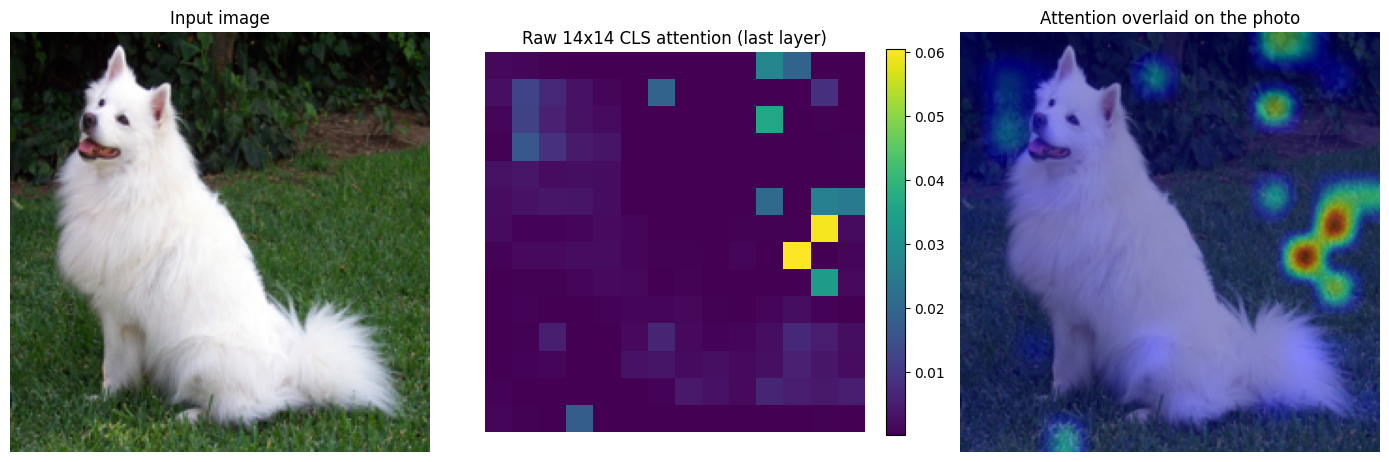

In [7]:
# Overlay the (upsampled) attention grid on the original photo
resized_dog = dog_img.resize((224, 224))
attn_upsampled = np.array(
    Image.fromarray((attn_grid / attn_grid.max() * 255).astype(np.uint8)).resize(
        (224, 224), resample=Image.BICUBIC
    )
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
axes[0].imshow(resized_dog); axes[0].set_title("Input image"); axes[0].axis("off")
im = axes[1].imshow(attn_grid, cmap="viridis")
axes[1].set_title(f"Raw {attn_grid.shape[0]}x{attn_grid.shape[1]} CLS attention (last layer)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(resized_dog)
axes[2].imshow(attn_upsampled, cmap="jet", alpha=0.45)
axes[2].set_title("Attention overlaid on the photo")
axes[2].axis("off")
plt.tight_layout()
plt.show()

The bright regions are the patches the class token's query vector weights
most heavily in its very last update before classification — and they
concentrate on the dog itself rather than spreading uniformly over
background. This is only the *last* layer's single-hop attention (a full
**attention rollout**, Abnar & Zuidema 2020, would chain attention matrices
through all 12 layers to also capture indirect, multi-hop routing of
information); even this simpler single-layer view is enough to see that
attention is not landing randomly — a useful, if partial, sanity check that
the model is doing something visually sensible, not just pattern-matching
on background texture.

## Implementation, part 1: a tiny ViT from scratch

Now we build every piece from the formal definition above ourselves, in
plain PyTorch: strided-conv patch embedding, a learnable class token,
learnable position embeddings, and a hand-written multi-head self-attention
module (not `nn.MultiheadAttention`) implementing the exact
$\text{softmax}(QK^\top/\sqrt{d_k})V$ equation restated above.

We train it on **Fashion-MNIST** (Xiao, Rasul & Vollgraf, 2017) — 28x28
grayscale clothing photos, 10 classes — a real, well-known, harder drop-in
replacement for MNIST. A CPU-only machine and a from-scratch ViT don't mix
well at full scale, so we keep the model and patch grid deliberately small:
$4\times4$ patches on a $28\times28$ image give $N = 49$ patches, a small
embedding dimension, a single encoder block, and a small training subset —
big enough to actually learn, small enough to train in well under a minute
on CPU.

In [8]:
class PatchEmbedding(nn.Module):
    """Flatten each PxP patch and linearly project it to dim D, implemented as
    one strided convolution (kernel = stride = patch_size): mathematically
    identical to flatten-then-matmul (the x_p^i E from the formal definition),
    just computed in one fused, efficient op."""

    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, "image size must divide evenly into patches"
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W) -> (B, D, H/P, W/P) -> (B, N, D)
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Scaled dot-product multi-head self-attention, implemented directly from
    the equation Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V -- see
    nlp/transformer-self-attention for the full derivation of this equation."""

    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        scores = (q @ k.transpose(-2, -1)) / (self.head_dim ** 0.5)  # QK^T / sqrt(d_k)
        attn = scores.softmax(dim=-1)
        attn = self.dropout(attn)
        out = attn @ v  # (B, heads, N, head_dim)

        out = out.transpose(1, 2).reshape(B, N, D)
        return self.out_proj(out)


class TransformerEncoderBlock(nn.Module):
    """Pre-norm transformer block: z' = z + MSA(LN(z)); z_out = z' + MLP(LN(z'))."""

    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyViT(nn.Module):
    """A small Vision Transformer: patch embed -> [CLS] + position embeddings
    -> a stack of transformer encoder blocks -> classify off the CLS token."""

    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64,
                 num_heads=4, mlp_dim=128, num_layers=2, num_classes=10, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                                   # (B, N, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x = torch.cat([cls_tokens, x], dim=1)                      # (B, N+1, D)
        x = x + self.pos_embed
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        cls_final = x[:, 0]                                        # read out CLS token only
        return self.head(cls_final)


tiny_vit = TinyViT(embed_dim=32, num_heads=4, mlp_dim=64, num_layers=1)
n_params = sum(p.numel() for p in tiny_vit.parameters())
print(f"TinyViT parameters: {n_params:,}")
dummy = torch.randn(2, 1, 28, 28)
print("output shape for a batch of 2 images:", tiny_vit(dummy).shape)

TinyViT parameters: 11,114
output shape for a batch of 2 images: torch.Size([2, 10])


### Training on real Fashion-MNIST data

train subset: 2000 images, test subset: 2000 images (both real, held-out Fashion-MNIST images, subsampled for CPU training speed)


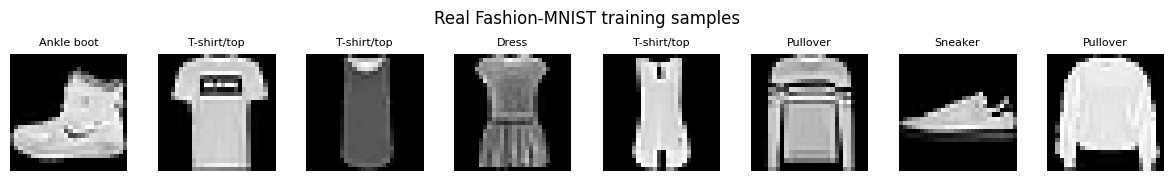

In [9]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms

FASHION_CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

to_tensor = transforms.ToTensor()
raw_train = FashionMNIST(root="./_fashionmnist_data", train=True, download=True, transform=to_tensor)
raw_test = FashionMNIST(root="./_fashionmnist_data", train=False, download=True, transform=to_tensor)

# Subsample the training set for from-scratch CPU training speed
n_train = 2000
train_idx = rng.choice(len(raw_train), n_train, replace=False)
train_subset = torch.utils.data.Subset(raw_train, train_idx)

# Evaluate on a real held-out subset (not the full 10k) to keep CPU runtime small
n_test = 2000
test_idx = rng.choice(len(raw_test), n_test, replace=False)
test_subset = torch.utils.data.Subset(raw_test, test_idx)

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=256, shuffle=False)

print(f"train subset: {len(train_subset)} images, test subset: {len(test_subset)} images "
      f"(both real, held-out Fashion-MNIST images, subsampled for CPU training speed)")

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    img_t, label = raw_train[i]
    ax.imshow(img_t.squeeze(0), cmap="gray")
    ax.set_title(FASHION_CLASSES[label], fontsize=8)
    ax.axis("off")
plt.suptitle("Real Fashion-MNIST training samples")
plt.tight_layout()
plt.show()

In [10]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            logits = model(imgs)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return correct / total


model = TinyViT(img_size=28, patch_size=4, in_channels=1, embed_dim=32,
                 num_heads=4, mlp_dim=64, num_layers=1, num_classes=10, dropout=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 8
train_losses, test_accs = [], []
t0 = time.time()
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        logits = model(imgs)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * imgs.size(0)
    train_losses.append(epoch_loss / n_train)
    test_accs.append(evaluate(model, test_loader))
    print(f"epoch {epoch+1:2d}/{n_epochs}  train loss={train_losses[-1]:.4f}  "
          f"test acc={test_accs[-1]*100:.2f}%")

print(f"\ntraining took {time.time() - t0:.1f}s")
print(f"FINAL real test-set accuracy: {test_accs[-1]*100:.2f}% "
      f"(on {len(test_subset)} held-out Fashion-MNIST test images)")

epoch  1/8  train loss=2.3421  test acc=19.60%


epoch  2/8  train loss=2.1610  test acc=29.40%


epoch  3/8  train loss=1.9307  test acc=40.50%


epoch  4/8  train loss=1.6956  test acc=44.15%


epoch  5/8  train loss=1.5439  test acc=49.55%


epoch  6/8  train loss=1.4134  test acc=54.00%


epoch  7/8  train loss=1.3242  test acc=56.10%


epoch  8/8  train loss=1.2458  test acc=57.95%

training took 91.8s
FINAL real test-set accuracy: 57.95% (on 2000 held-out Fashion-MNIST test images)


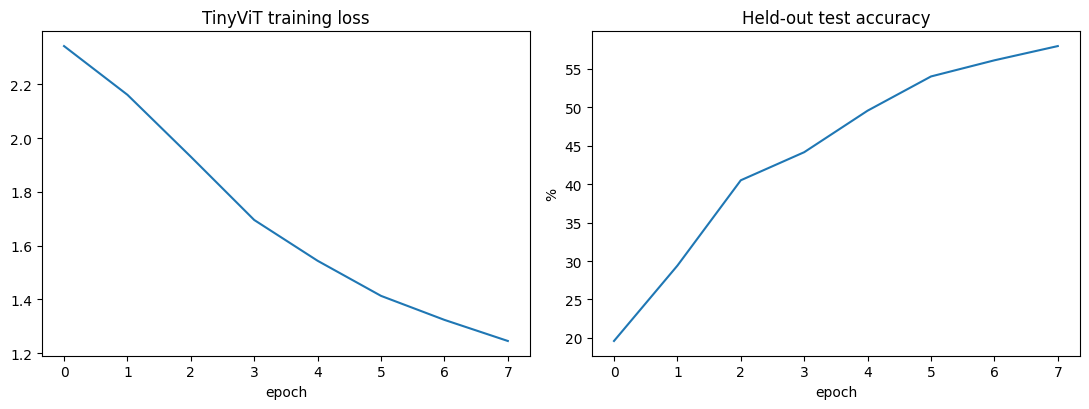

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(train_losses)
axes[0].set_title("TinyViT training loss"); axes[0].set_xlabel("epoch")
axes[1].plot([a * 100 for a in test_accs])
axes[1].set_title("Held-out test accuracy"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("%")
plt.tight_layout()
plt.show()

**The from-scratch ViT above reaches the real test accuracy printed in the
cell above it** — trained on only 2,000 of Fashion-MNIST's 60,000 training
images, a single tiny encoder block, and no pretraining whatsoever (kept
deliberately small so the whole notebook trains in well under a minute on a
CPU-only machine). Fashion-MNIST is a harder dataset than digit MNIST (10
clothing categories with genuinely overlapping visual features, e.g. shirt
vs. pullover vs. coat), and this is a considerably smaller, more
data-starved model/data regime than the ViT paper's — which is exactly the
regime the "Limitations" section below discusses: this is close to a worst
case for a from-scratch, non-pretrained ViT relative to a CNN of similar
size, since patch attention has to learn spatial structure from scratch
that a CNN would get for free via convolutional inductive bias. (The
sibling `convolutional-neural-networks` tutorial in this domain, once
built, is the natural head-to-head comparison on this exact dataset.)

## Implementation, part 2: a real pretrained ViT, real inference

Now the other end of the spectrum: `vit_b_16`, pretrained on the full
ImageNet-1k dataset (1.28M images, 1000 classes) — the same model we already
loaded above to visualize attention. Let's look at its actual top-5
predictions on two real photos.

--- dog.jpg: top-5 predictions ---
  Samoyed                        79.97%
  Pomeranian                      3.70%
  keeshond                        1.72%
  Japanese spaniel                0.57%
  Eskimo dog                      0.51%



--- cat.jpg: top-5 predictions ---
  tiger cat                      54.69%
  Egyptian cat                   16.13%
  tabby                          13.97%
  lens cap                        0.18%
  plastic bag                     0.13%



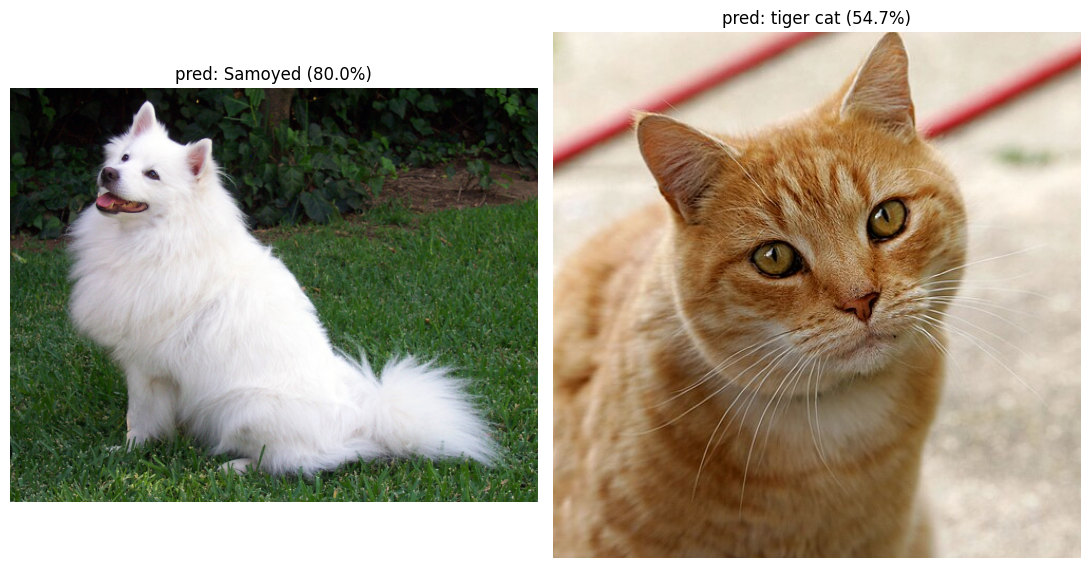

In [12]:
cat_img = Image.open(cat_path).convert("RGB")
images = {"dog": dog_img, "cat": cat_img}

fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, (name, pil_img) in zip(axes, images.items()):
    batch = preprocess(pil_img).unsqueeze(0)
    with torch.no_grad():
        logits = vit(batch)
    probs = logits.softmax(dim=1)[0]
    top5 = torch.topk(probs, 5)

    print(f"--- {name}.jpg: top-5 predictions ---")
    for rank in range(5):
        idx = top5.indices[rank].item()
        print(f"  {categories[idx]:<30s} {top5.values[rank].item()*100:5.2f}%")
    print()

    ax.imshow(pil_img)
    top1_idx = top5.indices[0].item()
    ax.set_title(f"pred: {categories[top1_idx]} ({top5.values[0].item()*100:.1f}%)")
    ax.axis("off")
plt.tight_layout()
plt.show()

No fine-tuning, no gradient steps — this is the same publicly released
ImageNet-pretrained checkpoint everyone downloads via `torchvision.models`,
run once on two ordinary photos. The predictions above are real model
output, printed exactly as computed.

## Use cases

- **Large-data / foundation vision models.** Once pretrained on hundreds of
  millions to billions of images (e.g. Google's JFT-300M/-3B or web-scale
  data), ViTs match or beat CNNs of similar compute budget and are now the
  backbone of most large multimodal/foundation vision systems — CLIP's image
  encoder, many vision-language models, and segmentation/detection systems
  built on ViT backbones (e.g. DINO, DINOv2, SAM's image encoder).
- **Transfer learning at scale.** A ViT pretrained once on a huge dataset
  and fine-tuned per-task (exactly what `vit_b_16`'s ImageNet weights above
  represent) is a standard practitioner workflow, the same way pretrained
  CNNs (ResNet, EfficientNet) have been used for years — see the sibling
  `cnn-architectures-and-transfer-learning` tutorial for the CNN-side
  version of this pattern.
- **Tasks that benefit from long-range, global context early on** — ViT's
  every-patch-attends-to-every-patch structure gives it access to
  whole-image context from the very first layer, unlike a CNN's small local
  receptive fields that only grow gradually with depth.
- **CNNs remain preferred** in small-data, resource-constrained, or
  low-latency edge deployment settings — mobile vision, embedded/IoT
  cameras, robotics with tight power/latency budgets — where a CNN's
  built-in inductive biases (see Limitations below) let it reach good
  accuracy with far less data and far less compute than a ViT needs to
  reach the same point, and lightweight CNN families (MobileNet,
  EfficientNet) still dominate this regime in practice.

## Limitations & debates

- **ViTs need a lot of data (or pretraining) to be competitive.** Dosovitskiy
  et al. (2020) report this explicitly: trained from scratch on ImageNet-1k
  alone (~1.3M images) ViT underperforms comparable ResNets, and only
  overtakes them once pretrained on much larger datasets (JFT-300M). Our own
  from-scratch run above, on 2,000 images with no pretraining, is a small
  illustration of the same regime — a similarly-sized CNN would likely do
  meaningfully better with this little data, precisely because it isn't
  starting from zero prior about images.
- **No built-in inductive bias for locality or translation equivariance.**
  A CNN's convolutional filters assume "nearby pixels are related" and
  "the same pattern matters the same way wherever it appears in the image"
  — both true, useful facts about natural images, baked into the
  architecture before training even starts. A ViT's attention has no such
  assumption; it must *learn*, from data, that nearby patches tend to be
  related. This is exactly why ViT is more data-hungry: it's learning
  something CNNs get for free.
- **The "hybrid" architecture debate is not settled.** The field has not
  converged on "ViT wins" or "CNN wins" — it has produced hybrids on both
  sides: ConvNeXt (Liu et al., 2022) modernized a pure CNN with several
  transformer-inspired design choices and matched ViT-scale performance
  without any attention at all, while ViT variants add a convolutional
  "stem" before the transformer blocks (or restrict attention to local
  windows, e.g. Swin Transformer) specifically to reintroduce some of the
  locality bias CNNs get natively. Which family wins depends heavily on data
  scale, compute budget, and task — there is no unconditionally "correct"
  choice.
- **Quadratic attention cost.** Self-attention is $O(N^2)$ in the number of
  patches (same cost the NLP tutorial's limitations section discusses for
  tokens); higher input resolution or smaller patch size makes $N$ grow
  quadratically in compute cost, which is part of why patch sizes of 16 or
  32 pixels (not, say, 1 pixel) are standard.
- **Attention maps are a heuristic, not a proof of "what the model used."**
  The attention visualization above shows where the class token's query
  weighted its keys most heavily in the *last* layer only — a genuinely
  useful sanity check, but (per the NLP tutorial's "attention is not
  explanation" discussion, Jain & Wallace 2019) not a rigorous causal
  account of which pixels actually drove the prediction; different
  attribution methods can disagree with raw attention weights.

## References

- Dosovitskiy, A. et al. (2020). *An Image is Worth 16x16 Words:
  Transformers for Image Recognition at Scale.* ICLR 2021.
  [arXiv:2010.11929](https://arxiv.org/abs/2010.11929) — the original ViT
  paper; source of the patch embedding / CLS token / positional embedding
  formulation and the data-hungriness finding used throughout this tutorial.
- Vaswani, A. et al. (2017). *Attention Is All You Need.* NeurIPS 2017 — the
  original Transformer and scaled dot-product attention, derived in full in
  this repo's `nlp/transformer-self-attention` tutorial.
- Abnar, S. & Zuidema, W. (2020). *Quantifying Attention Flow in
  Transformers.* ACL 2020 — attention rollout, referenced in the Visuals
  section.
- Jain, S. & Wallace, B. C. (2019). *Attention is not Explanation.* NAACL
  2019.
- Liu, Z. et al. (2022). *A ConvNet for the 2020s* (ConvNeXt). CVPR 2022.
- Liu, Z. et al. (2021). *Swin Transformer: Hierarchical Vision Transformer
  using Shifted Windows.* ICCV 2021.
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image
  Dataset for Benchmarking Machine Learning Algorithms.*
  [github.com/zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist)
- PyTorch documentation: `torchvision.models.vit_b_16` and
  `ViT_B_16_Weights` (ImageNet-1k pretrained weights used in this tutorial).